In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fraud-detection/fraudTest.csv
/kaggle/input/fraud-detection/fraudTrain.csv


In [2]:
df=pd.read_csv('/kaggle/input/fraud-detection/fraudTrain.csv')
df.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [3]:
df.shape

(1296675, 23)

In [4]:
df.shape
df['is_fraud'].value_counts()
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

In [5]:
df_sample = df.sample(200000, random_state=42)
df_sample['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994055
1    0.005945
Name: proportion, dtype: float64

# 1️⃣ Basic Probability Using Real Fraud Dataset



Probability Formula:

P(A) = (Number of times event occurs) / (Total number of observations)

In this dataset:

Event A = Transaction is Fraud

In [6]:
# Total transactions
total_transactions = len(df_sample)

# Fraud transactions
fraud_count = df_sample['is_fraud'].sum()

# Not fraud transactions
non_fraud_count = total_transactions - fraud_count

# probabilities
p_fraud = fraud_count / total_transactions
p_non_fraud = non_fraud_count / total_transactions

p_fraud, p_non_fraud

(np.float64(0.005945), np.float64(0.994055))

**There is approximately 0.59% probability that a randomly selected transaction is fraudulent.**

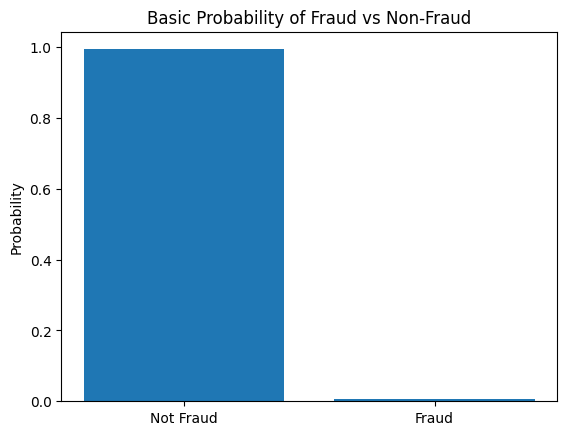

In [7]:
import matplotlib.pyplot as plt

labels = ['Not Fraud', 'Fraud']
values = [p_non_fraud, p_fraud]

plt.bar(labels, values)
plt.title("Basic Probability of Fraud vs Non-Fraud")
plt.ylabel("Probability")
plt.show()

# 2️⃣ Conditional Probability

Conditional probability measures the probability of an event occurring 
given that another event has already occurred.

Formula:

P(A | B) = P(A and B) / P(B)

We will calculate:

1. P(Fraud | Gender = Female)
2. P(Fraud | High Transaction Amount)

In [8]:
# Filter female transactions
female_df = df_sample[df_sample['gender'] == 'F']

# Count frauds among females
fraud_female = female_df['is_fraud'].sum()

# Total female transactions
total_female = len(female_df)

# Conditional probability
p_fraud_given_female = fraud_female / total_female

p_fraud_given_female

np.float64(0.005229416613242971)

In [9]:
# Define threshold for high amount (90th percentile)
threshold = df_sample['amt'].quantile(0.90)

# Filter high amount transactions
high_amt_df = df_sample[df_sample['amt'] >= threshold]

# Calculate conditional probability
fraud_high_amt = high_amt_df['is_fraud'].sum()
total_high_amt = len(high_amt_df)

p_fraud_given_high_amt = fraud_high_amt / total_high_amt

p_fraud_given_high_amt

np.float64(0.04645)

## Insight

The base fraud probability is approximately 0.59%.

However:

P(Fraud | High Amount) ≈ 4.64%

This indicates that high transaction amounts increase fraud likelihood 
by nearly 8 times compared to baseline probability.

This demonstrates how conditional probability helps identify risk factors 
in fraud detection.

# 3️⃣ Bayes Theorem

Bayes theorem allows us to update probability 
based on new evidence.

In our dataset:

A = Fraud  
B = High Transaction Amount  

We will verify: P(Fraud | High Amount)= P(High Amount | Fraud) × P(Fraud) / P(High Amount)



In [10]:
#  Prior: P(Fraud)
p_fraud = df_sample['is_fraud'].mean()

#  P(High Amount)
threshold = df_sample['amt'].quantile(0.90)
p_high_amt = (df_sample['amt'] >= threshold).mean()

# P(High Amount | Fraud)
fraud_df = df_sample[df_sample['is_fraud'] == 1]
p_high_given_fraud = (fraud_df['amt'] >= threshold).mean()

p_fraud, p_high_amt, p_high_given_fraud

(np.float64(0.005945), np.float64(0.1), np.float64(0.7813288477712363))

In [11]:
# Bayes Theorem
p_fraud_given_high_bayes = (p_high_given_fraud * p_fraud) / p_high_amt

p_fraud_given_high_bayes

np.float64(0.04645)

## Bayes Theorem Verification

Prior:
P(Fraud) ≈ 0.0059

Likelihood:
P(High Amount | Fraud) ≈ 0.7813

Evidence:
P(High Amount) = 0.10

Posterior (Bayes Result):
P(Fraud | High Amount) ≈ 0.04645

This confirms that high-value transactions significantly increase fraud risk.

Bayes theorem allows us to update probability using evidence.

# 4️⃣ Permutation and Combination

Permutation:
Order matters.

Combination:
Order does not matter.

In data science, combination is commonly used 
for feature selection and model experimentation.

In [12]:
import math

def permutation(n, r):
    return math.factorial(n) // math.factorial(n - r)

def combination(n, r):
    return math.factorial(n) // (math.factorial(r) * math.factorial(n - r))

# Example: 5 features, choose 3
n = 5
r = 3

perm_result = permutation(n, r)
comb_result = combination(n, r)

perm_result, comb_result

(60, 10)

In [13]:
features = ['amt', 'gender', 'category', 'city_pop', 'job']

n = len(features)
r = 3

math.comb(n, r)

10

## Why Permutation and Combination Matter

As the number of features increases,
the number of possible combinations grows rapidly.

This explains why exhaustive feature selection 
becomes computationally expensive in large datasets.